In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Įsikelkite duomenis

In [3]:
df = pd.read_csv(r"C:\BIT_Data_analyst\04_statistics\lectures\03_lesson\automobiliai.csv")

Apskaičiuokite pagrindinę aprašomąją statistiką

In [4]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
kuro_sanaudos,392.0,23.45,7.81,9.0,17.00,22.75,29.00,46.6
cilindrai,392.0,5.47,1.71,3.0,4.00,4.00,8.00,8.0
arklio_galios,392.0,104.47,38.49,46.0,75.00,93.50,126.00,230.0
svoris,392.0,2977.58,849.40,1613.0,2225.25,2803.50,3614.75,5140.0
isibegejimas,392.0,15.54,2.76,8.0,13.78,15.50,17.02,24.8
gamybos_metai,392.0,75.98,3.68,70.0,73.00,76.00,79.00,82.0


Kaip pasiskirsčiusios kuro sąnaudos? pavaizduokite grafiškai

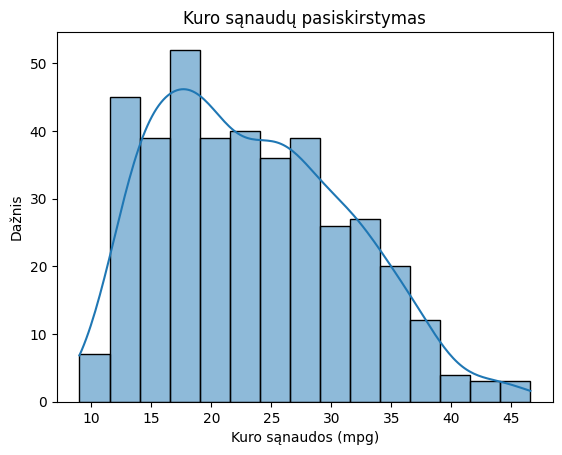

In [5]:
sns.histplot(df["kuro_sanaudos"], bins=15, kde=True)
plt.title("Kuro sąnaudų pasiskirstymas")
plt.xlabel("Kuro sąnaudos (mpg)")
plt.ylabel("Dažnis")
plt.show()


Kaip pasiskirsčiusios Arklio galios? pavaizduokite grafiškai

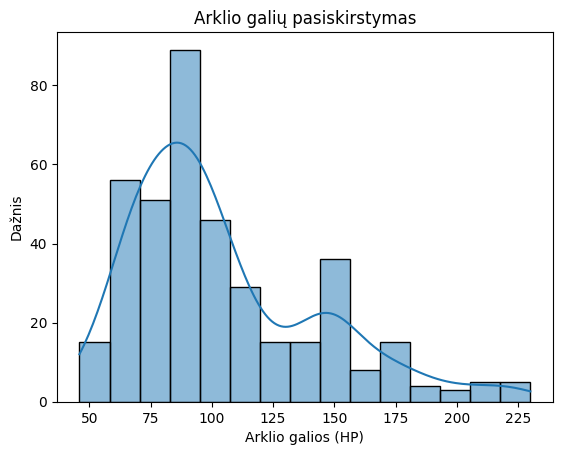

In [6]:
sns.histplot(df["arklio_galios"], bins=15, kde=True)
plt.title("Arklio galių pasiskirstymas")
plt.xlabel("Arklio galios (HP)")
plt.ylabel("Dažnis")
plt.show()


Koks vidutinis automobilių svoris?

In [7]:
mean = df["svoris"].mean().round(2)
print("Vidurkis =", mean)

Vidurkis = 2977.58


Apskaičiuokite koreliacijos matricą

In [10]:
df_numeric = df.select_dtypes(include=["number"])
df_numeric.corr()


,kuro_sanaudos,cilindrai,arklio_galios,svoris,isibegejimas,gamybos_metai
kuro_sanaudos,1.000000,-0.777618,-0.778427,-0.832244,0.423329,0.580541
cilindrai,-0.777618,1.000000,0.842983,0.897527,-0.504683,-0.345647
arklio_galios,-0.778427,0.842983,1.000000,0.864538,-0.689196,-0.416361
svoris,-0.832244,0.897527,0.864538,1.000000,-0.416839,-0.309120
isibegejimas,0.423329,-0.504683,-0.689196,-0.416839,1.000000,0.290316
gamybos_metai,0.580541,-0.345647,-0.416361,-0.309120,0.290316,1.000000


Nubraižykite koreliacijos matricos šilumos žemėlapį

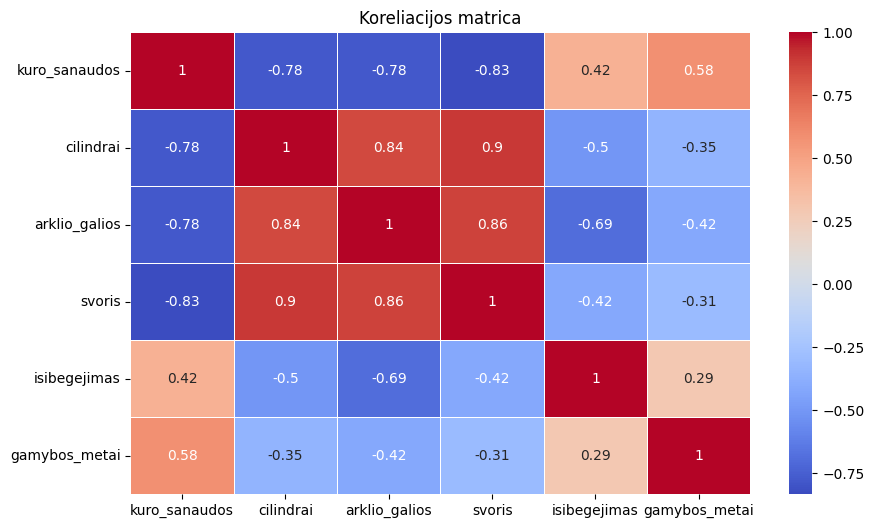

In [12]:
df_numeric = df.select_dtypes(include=["number"])

plt.figure(figsize=(10, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Koreliacijos matrica")
plt.show()


Ar yra ryšis tarp kintamųjų? ar galite apibūdinti koks?

In [ ]:
Sunkesni ir daugiau cilindrų turintys automobiliai paprastai turi didesnes arklio galias ir sunaudoja daugiau kuro, 
todėl svoris, cilindrai ir galia yra stipriai teigiamai susiję tarpusavyje, 
o visi trys turi stiprų neigiamą ryšį su kuro sąnaudomis (mpg).

Nubraižykite svorio ir kuro sąnaudų sklaidos grafiką

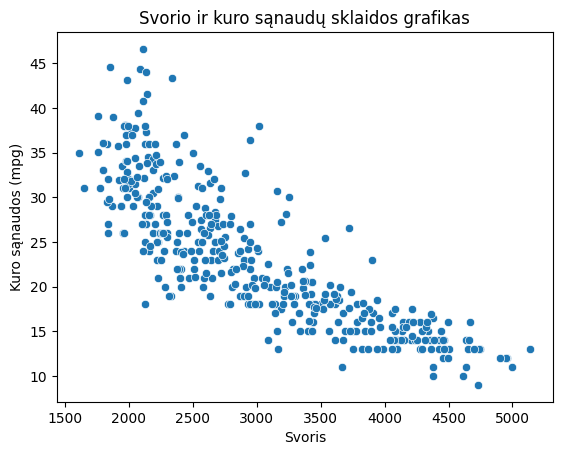

In [13]:
sns.scatterplot(x="svoris", y="kuro_sanaudos", data=df)
plt.title("Svorio ir kuro sąnaudų sklaidos grafikas")
plt.xlabel("Svoris")
plt.ylabel("Kuro sąnaudos (mpg)")
plt.show()


Nubraižykite arklio galių ir kuro sąnaudų sklaidos grafiką

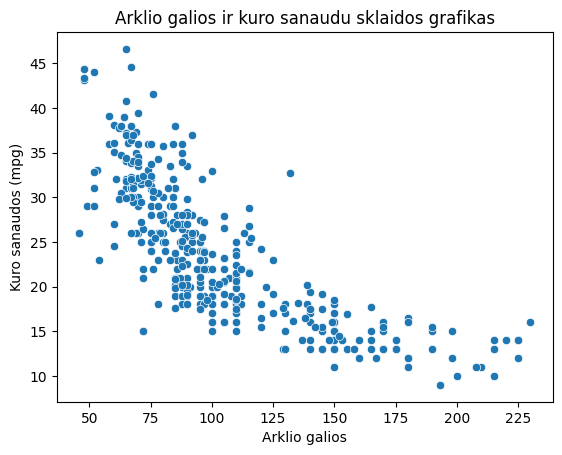

In [15]:
sns.scatterplot(x="arklio_galios", y="kuro_sanaudos", data=df)
plt.title("Arklio galios ir kuro sanaudu sklaidos grafikas")
plt.xlabel("Arklio galios")
plt.ylabel("Kuro sanaudos (mpg)")
plt.show()

Ar yra reikšmingas kuro sąnaudų skirtumas tarp automobilių su 4 ir 8 cilindrais

In [16]:
df.groupby("cilindrai")["kuro_sanaudos"].mean()


cilindrai
3    20.550000
4    29.283920
5    27.366667
6    19.973494
8    14.963107
Name: kuro_sanaudos, dtype: float64

Automobiliai su 4 cilindrais vidutiniškai sunaudoja beveik dvigubai mažiau kuro nei 8 cilindrų automobiliai, todėl skirtumas tarp jų yra labai reikšmingas.

Apskaičiuokite pasikliautinąjį intervalą vidutinėms kuro sąnaudoms su 95% reikšmingumo lygiu

In [20]:
mpg = df["kuro_sanaudos"] 
mean = mpg.mean() 
std = mpg.std() 
n = len(mpg) 
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n)) 
ci

(np.float64(22.670877187773105), np.float64(24.22095954692077))

Apskaičiuokite pasikliautinąjį intervalą vidutiniam svoriu su 99% reikšmingumo lygiu

In [ ]:
svoris = df["svoris"]
mean = svoris.mean()
std = svoris.std()
n = len(svoris)
ci = stats.t.interval(0.99, df=n-1, loc=mean, scale=std/np.sqrt(n))
ci

(np.float64(2866.535796255103), np.float64(3088.632571091836))